## 1. What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning

Deep Learning is a branch of **Machine Learning** that uses multi-layered **neural networks** to automatically learn features and patterns from data, especially unstructured data like images, text, and audio.

**Evolution:**

* 1950s–1980s: Early neural networks (Perceptron).
* 1986: Backpropagation improved training.
* 1990s–2000s: Traditional ML (SVMs, Decision Trees) dominated.
* 2010s+: Rise of Big Data + GPUs → Deep Learning breakthroughs (CNNs, RNNs, Transformers).

**Difference from ML:**

* **ML** → needs manual feature engineering, works with small data.
* **DL** → learns features automatically, requires large data + GPUs, excels in complex tasks (vision, NLP, speech).


## 2. Explain the basic architecture and functioning of a Perceptron. What are its limitations?

**Basic Architecture:**

* The **Perceptron** is the simplest type of artificial neural network (introduced by Frank Rosenblatt in 1958).
* It consists of:

  1. **Input layer** – takes feature values.
  2. **Weights** – each input has a weight showing importance.
  3. **Summation function** – computes weighted sum $z = \sum w_i x_i + b$.
  4. **Activation function** (usually step function) – outputs either 0 or 1 based on threshold.

**Functioning:**

1. Inputs $x_1, x_2, …, x_n$ are multiplied with weights $w_1, w_2, …, w_n$.
2. Bias $b$ is added.
3. Activation function decides the output (e.g., class 0 or 1).

---

**Limitations:**

* Works only for **linearly separable problems** (fails for XOR).
* Can’t learn complex, non-linear relationships.
* Uses simple step activation (no gradient → can’t use gradient descent effectively).
* Limited to binary classification, not suitable for multi-class or deep tasks.

---

**In short:** A perceptron is a simple linear classifier with weighted inputs, summation, and activation. Its major limitation is inability to solve non-linear problems, which led to the development of **multi-layer perceptrons (MLPs)**.



## 3. Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.

**Purpose:**

* The **activation function** introduces **non-linearity** into a neural network.
* Without it, the network would just be a linear model (like simple regression).
* It helps the network learn **complex patterns** and decide which neurons should be activated.

---

### **Common Activation Functions**

| Function    | Formula                                    | Range   | Pros                                             | Cons                                                         |
| ----------- | ------------------------------------------ | ------- | ------------------------------------------------ | ------------------------------------------------------------ |
| **Sigmoid** | $f(x) = \frac{1}{1+e^{-x}}$                | (0, 1)  | Smooth, probabilistic interpretation             | Vanishing gradient, slow learning, outputs not zero-centered |
| **Tanh**    | $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | (-1, 1) | Zero-centered, stronger gradients than Sigmoid   | Still suffers vanishing gradient                             |
| **ReLU**    | $f(x) = \max(0, x)$                        | \[0, ∞) | Fast training, avoids vanishing gradient, simple | “Dead neurons” (negative inputs → 0), unbounded output       |

---

**In short:**

* Activation functions give neural networks the ability to learn **non-linear mappings**.
* **Sigmoid** → good for probabilities, but slow.
* **Tanh** → better than Sigmoid, zero-centered.
* **ReLU** → most popular, fast & efficient, but can cause dead neurons.


## 4. What is the difference between Loss function and Cost function in neural networks? Provide examples.

**Loss Function:**

* Measures the **error for a single training example**.
* Tells how far the predicted output is from the actual output.
* Example:

  * **Mean Squared Error (MSE) Loss (per sample):**

    $$
    L = (y - \hat{y})^2
    $$

**Cost Function:**

* Measures the **average error over the entire training dataset**.
* It’s basically the mean of all individual losses.
* Example:

  * **MSE Cost Function:**

    $$
    J = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2
    $$

---

### **Key Difference**

| Aspect  | Loss Function                        | Cost Function                                  |
| ------- | ------------------------------------ | ---------------------------------------------- |
| Scope   | Single training example              | Entire dataset (average loss)                  |
| Usage   | Evaluates one prediction             | Evaluates model performance                    |
| Example | Error for one house price prediction | Average error over all house price predictions |

---

* **Loss function = error for one sample.**
* **Cost function = average of losses across all samples.**

## 5. What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.

**Role:**
Optimizers are algorithms used to **adjust the weights and biases** of a neural network to minimize the **cost function**. They guide how the model learns by updating parameters during training.

---

### **Comparison of Optimizers**

| Optimizer                             | Key Idea                                                                                                              | Pros                                                                | Cons                                                                               |
| ------------------------------------- | --------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| **Gradient Descent (GD)**             | Updates weights by moving in the direction of the negative gradient of cost function.                                 | Simple, works for convex problems.                                  | Slow on large datasets, may get stuck in local minima, sensitive to learning rate. |
| **RMSprop**                           | Uses exponentially decaying average of squared gradients to adapt learning rate for each parameter.                   | Works well for non-stationary data, faster convergence than GD.     | Learning rate still needs tuning, may not generalize well.                         |
| **Adam (Adaptive Moment Estimation)** | Combines **Momentum + RMSprop** (keeps track of both first moment = mean, and second moment = variance of gradients). | Fast, efficient, less tuning needed, widely used default optimizer. | Can sometimes overfit or converge to suboptimal solutions.                         |

---


In [3]:
# 6. Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.

import numpy as np

# Training data for AND gate
# Inputs
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
# Expected outputs
y = np.array([0, 0, 0, 1])

# Initialize weights and bias
weights = np.random.rand(2)   # 2 inputs
bias = np.random.rand(1)
learning_rate = 0.1
epochs = 20

# Activation function (Step function)
def step_function(x):
    return np.where(x >= 0, 1, 0)

# Training loop
for epoch in range(epochs):
    total_error = 0
    for i in range(len(X)):
        # Weighted sum
        z = np.dot(X[i], weights) + bias
        # Prediction
        y_pred = step_function(z)
        # Error
        error = y[i] - y_pred
        total_error += abs(error)
        # Weight and bias update
        weights += learning_rate * error * X[i]
        bias += learning_rate * error
    print(f"Epoch {epoch+1}: Total Error = {total_error}")

print("\nFinal Weights:", weights)
print("Final Bias:", bias)

# Testing perceptron on AND gate inputs
print("\nTesting AND Gate Perceptron:")
for i in range(len(X)):
    z = np.dot(X[i], weights) + bias
    y_pred = step_function(z)
    print(f"{X[i]} => {y_pred}")


Epoch 1: Total Error = [3]
Epoch 2: Total Error = [1]
Epoch 3: Total Error = [1]
Epoch 4: Total Error = [2]
Epoch 5: Total Error = [2]
Epoch 6: Total Error = [1]
Epoch 7: Total Error = [0]
Epoch 8: Total Error = [0]
Epoch 9: Total Error = [0]
Epoch 10: Total Error = [0]
Epoch 11: Total Error = [0]
Epoch 12: Total Error = [0]
Epoch 13: Total Error = [0]
Epoch 14: Total Error = [0]
Epoch 15: Total Error = [0]
Epoch 16: Total Error = [0]
Epoch 17: Total Error = [0]
Epoch 18: Total Error = [0]
Epoch 19: Total Error = [0]
Epoch 20: Total Error = [0]

Final Weights: [0.39600755 0.18177539]
Final Bias: [-0.52272708]

Testing AND Gate Perceptron:
[0 0] => [0]
[0 1] => [0]
[1 0] => [0]
[1 1] => [1]


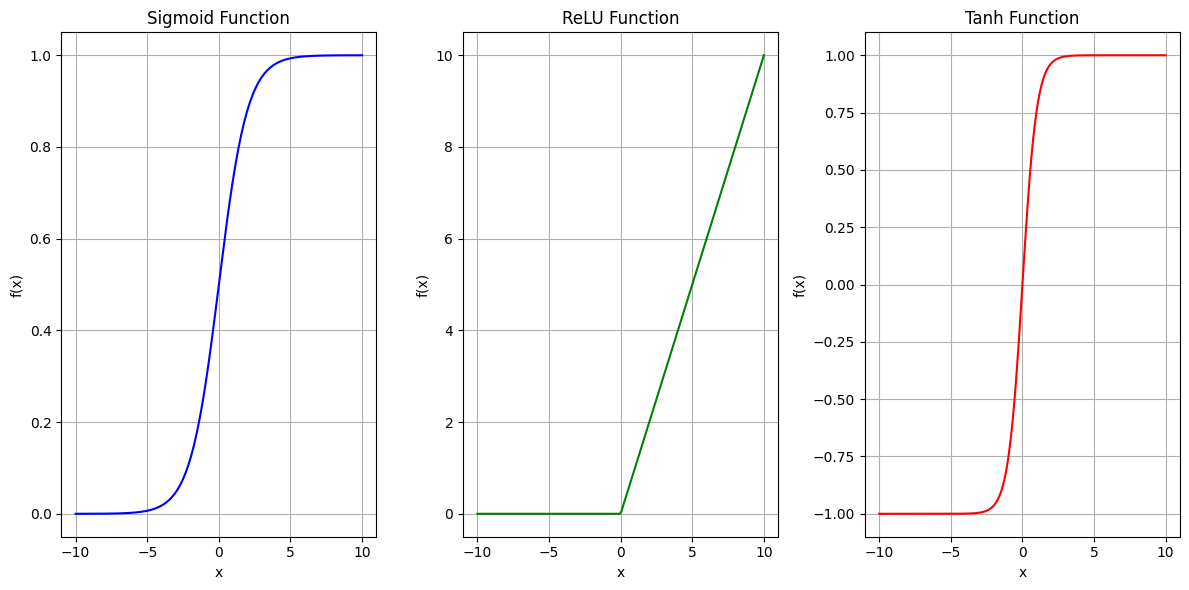

In [4]:
# 7. Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.

import numpy as np
import matplotlib.pyplot as plt

# Define activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# Generate input values
x = np.linspace(-10, 10, 200)

# Compute outputs
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_tanh = tanh(x)

# Plotting
plt.figure(figsize=(12, 6))

# Sigmoid
plt.subplot(1, 3, 1)
plt.plot(x, y_sigmoid, 'b')
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

# ReLU
plt.subplot(1, 3, 2)
plt.plot(x, y_relu, 'g')
plt.title("ReLU Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

# Tanh
plt.subplot(1, 3, 3)
plt.plot(x, y_tanh, 'r')
plt.title("Tanh Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [5]:
# 8. Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy.

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize inputs (0–1 range)
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build neural network model
model = Sequential([
    Flatten(input_shape=(28, 28)),        # Flatten 28x28 images into 784 vector
    Dense(128, activation='relu'),        # Hidden layer
    Dense(64, activation='relu'),         # Hidden layer
    Dense(10, activation='softmax')       # Output layer (10 classes)
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(x_train, y_train,
                    epochs=5,
                    batch_size=128,
                    verbose=1)

# Print final training accuracy
final_acc = history.history['accuracy'][-1]
print(f"\nFinal Training Accuracy: {final_acc:.4f}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


d:\PWSkills\PW_Skills_Assignments\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9046 - loss: 0.3333
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9609 - loss: 0.1323
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9727 - loss: 0.0918
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9801 - loss: 0.0685
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9835 - loss: 0.0539

Final Training Accuracy: 0.9835


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8100 - loss: 0.5489 - val_accuracy: 0.8254 - val_loss: 0.4855
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8582 - loss: 0.3975 - val_accuracy: 0.8603 - val_loss: 0.3951
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8726 - loss: 0.3526 - val_accuracy: 0.8672 - val_loss: 0.3740
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8830 - loss: 0.3218 - val_accuracy: 0.8582 - val_loss: 0.3883
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8892 - loss: 0.3031 - val_accuracy: 0.8658 - val_loss: 0.3779
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8944 - loss: 0.2868 - val_accuracy: 0.8713 - val_loss: 0.3596
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7

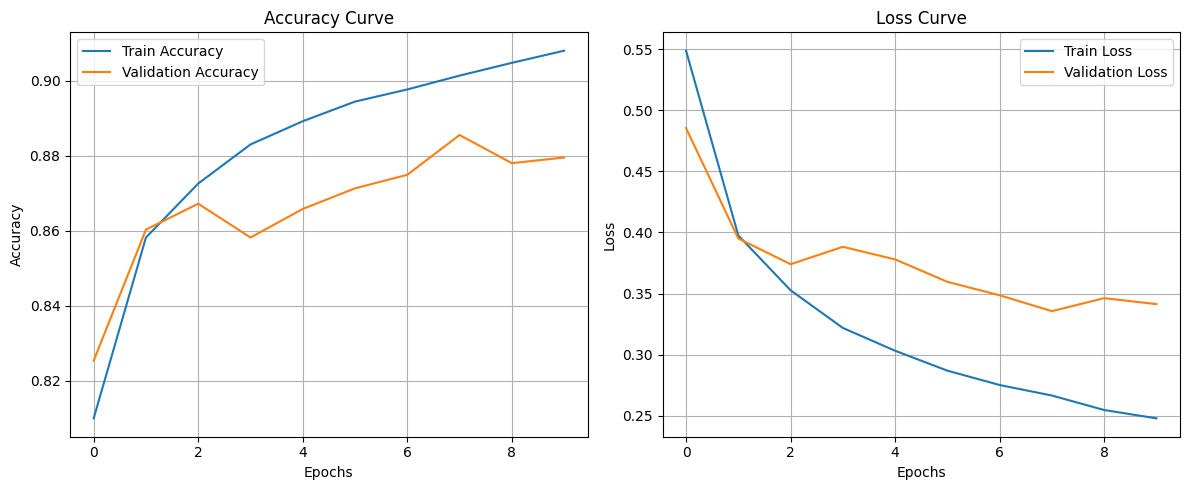

In [6]:
# 9. Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior.

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize data (0–1 range)
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_data=(x_test, y_test),
                    verbose=1)

# Plot Accuracy and Loss curves
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# 10. You are working on a project for a bank that wants to automatically detect
# fraudulent transactions. The dataset is large, imbalanced, and contains structured
# features like transaction amount, merchant ID, and customer location. The goal is to
# classify each transaction as fraudulent or legitimate.
# Explain your real-time data science workflow:
# ● How would you design a deep learning model (perceptron or multilayer NN)?
# ● Which activation function and loss function would you use, and why?
# ● How would you train and evaluate the model, considering class imbalance?
# ● Which optimizer would be suitable, and how would you prevent overfitting?



### **1. Designing the Deep Learning Model**

* **Input Layer:**

  * Features like `transaction_amount`, `merchant_ID`, `customer_location`, `time_of_day`, etc.
  * Normalize numerical features and one-hot encode categorical features (like merchant ID, location).

* **Hidden Layers:**

  * Use a **Multilayer Perceptron (MLP)** with 2–3 hidden layers.
  * Example: 64 → 32 → 16 neurons per layer.

* **Output Layer:**

  * Single neuron with **sigmoid activation** (for binary classification: fraudulent or legitimate).

**Architecture Example:**

```
Input → Dense(64, ReLU) → Dense(32, ReLU) → Dense(16, ReLU) → Dense(1, Sigmoid)
```

---

### **2. Activation & Loss Function**

* **Activation Functions:**

  * **Hidden layers:** ReLU (efficient, prevents vanishing gradient).
  * **Output layer:** Sigmoid (outputs probability between 0 and 1).

* **Loss Function:**

  * **Binary Cross-Entropy Loss** (suitable for binary classification).
  * Formula:

    $$
    L = - \frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y_i}) + (1-y_i) \log(1-\hat{y_i})]
    $$

---

### **3. Handling Class Imbalance**

* Fraud datasets are usually highly imbalanced (fraud < 1%). Options:

  1. **Resampling:**

     * Oversample minority class (fraud) using **SMOTE** or random oversampling.
     * Undersample majority class (legitimate transactions).
  2. **Class Weights:**

     * Assign higher weight to fraud class in the loss function.

     ```python
     class_weight = {0: 1, 1: 10}  # example: fraud is weighted higher
     ```
* **Evaluation Metrics:**

  * **Accuracy** is misleading; use **Precision, Recall, F1-score, ROC-AUC**.

---

### **4. Optimizer & Overfitting Prevention**

* **Optimizer:**

  * **Adam** – adaptive learning rate, fast convergence, widely used for tabular data.

* **Preventing Overfitting:**

  * **Dropout layers** (e.g., 0.2–0.5) in hidden layers.
  * **Early stopping** on validation loss.
  * **Regularization:** L2 weight decay.

---

### **5. Training & Evaluation Workflow**

1. **Preprocessing:** Normalize numerical features, encode categorical ones.
2. **Split data:** Train/validation/test split (e.g., 70/15/15).
3. **Apply class weighting or resampling** during training.
4. **Train model:** Use mini-batches, monitor validation loss.
5. **Evaluate model:** Use metrics suited for imbalanced data:

   * Confusion matrix, Precision, Recall, F1-score, ROC-AUC.
6. **Deploy in real-time:**

   * Use a **batch or streaming inference pipeline**.
   * Monitor model drift and retrain periodically.

---

**Summary:**

* **Model:** Multilayer perceptron (MLP).
* **Activation:** ReLU (hidden), Sigmoid (output).
* **Loss:** Binary cross-entropy.
* **Optimizer:** Adam.
* **Imbalance Handling:** Class weights, oversampling, evaluation with F1/ROC-AUC.
* **Overfitting Prevention:** Dropout, early stopping, L2 regularization.

---

